# PCA - PRINCIPAL COMPONENT ANALYSIS

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Import visualization packages.
import seaborn as sns
import matplotlib.pyplot as plt

#PCA
from sklearn.decomposition import PCA

#load the scaler
import joblib

PCA is useful to get insights about which variables contribute the most to variance.  In this case, PCA will be performed on our enginerred dataset.
  
PCA needs standardized variables. Hence, the engineered dataset is loaded and then scaled.

Note. Since the PCA is meant for exploratory analysis and PCs will not work as variables plugegd into the model, A new scaler is employed. If PCs would be fed into the model, then scaler_x.pkl must be the preferred choice.

In [2]:
#load the dataset
#load the dataset
df = pd.read_csv("../data/crypto_volatility_fe_ewm_noSTD.csv", index_col=0)
#show it
print('Original dataset first 5 rows:')
print(df.head())
print()

Original dataset first 5 rows:
         date    close        volume  trend  fg_index  cluster  log_return  \
0  2018-02-07  7599.00  60778.460497     49      36.0        0   -0.006969   
1  2018-02-08  7784.02   1521.537318     41      30.0        0    0.024056   
2  2018-02-09  8683.92  20482.910825     35      44.0        0    0.109400   
3  2018-02-10  8533.98  49381.512653     28      54.0        0   -0.017417   
4  2018-02-11  8063.88  45025.187952     25      31.0        4   -0.056661   

   hl_spread  momentum_3    vol_change  volatility  
0    1325.99     -585.81 -39423.039810    0.074001  
1     271.91      844.03 -59256.923179    0.047295  
2     948.10     1031.78  18961.373507    0.058076  
3     945.78      934.98  28898.601828    0.063501  
4     822.47      279.86  -4356.324701    0.069856  



As the target is not usually included when performing PCA, "volatility" is dropped. The column "date" is removed too as it does not add any information.  
  
Finally, cluster is not considered as it is NOT a continuous variable.

In [3]:
#drop the target variable
df = df.drop(columns = ['volatility', 'date', 'cluster'])
#show the updated columns
df.columns

Index(['close', 'volume', 'trend', 'fg_index', 'log_return', 'hl_spread',
       'momentum_3', 'vol_change'],
      dtype='object')

Finally, let's scale the dataset.

In [4]:
#define the scaler
scaler = StandardScaler()
#drop date
#get columns names
var_names = df.columns.tolist()
#scale the dataset
df_scaled = scaler.fit_transform(df)
#convert to a df
df_scaled = pd.DataFrame(df_scaled, columns = var_names)
#show the scaled dataset
print('Scaled dataset first 5 rows:')
print(df_scaled.head())

Scaled dataset first 5 rows:
      close    volume     trend  fg_index  log_return  hl_spread  momentum_3  \
0 -0.926441 -0.117065  0.824375 -0.504236   -0.225844  -0.101524   -0.335214   
1 -0.919158 -0.857888  0.388814 -0.779188    0.658452  -0.757444    0.364905   
2 -0.883733 -0.620835  0.062143 -0.137632    3.090984  -0.336673    0.456837   
3 -0.889636 -0.259548 -0.318972  0.320621   -0.523655  -0.338116    0.409439   
4 -0.908141 -0.314010 -0.482308 -0.733362   -1.642210  -0.414848    0.088660   

   vol_change  
0   -1.029339  
1   -1.547592  
2    0.496228  
3    0.755884  
4   -0.113056  


Once the dataset is standardized, it is possible to apply PCA. PCA helps in understanding how much variance (i.e changes) each principal compoenets explains.

In [5]:
#initilize PCA
pca = PCA()
#fit PCA on the scaled df
pca.fit(df_scaled)
#transform data
df_pca = pca.transform(df_scaled)

During the PCA process, it is fundamental to identify how many components (PCs) should be kept. The explained variance ratio guides this decision.  
  
To do that, let's build the scree plot.

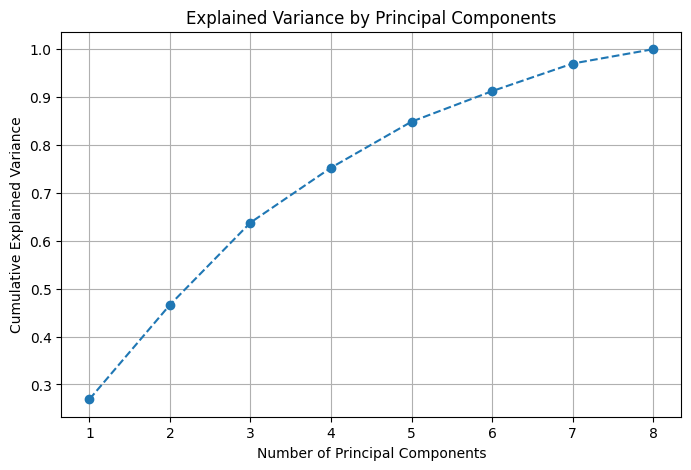

In [6]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

The chart shows how the variance explained increases with PCs without experiencing drastic swings.  
  
Let's set an arbitrary threshold of 80% of variance explained and check how many PCs are needed. According to the chart, they should be either 5.

In [ ]:
# Keep components that explain 80% of variance
pca = PCA(n_components=0.80)
df_pca_reduced = pca.fit_transform(df_scaled)
#print the PCA shape
print(f'Shape after PCA: {df_pca_reduced.shape}')

Shape after PCA: (2638, 5)


Now it is clear that 5 PCs explains more than 75% of the variance. Even though this is quite insightful per sè,  let's focus on the df variables and display how much each single variable contributes to each PC

In [14]:
#define the entire variables
features = var_names
# build a df for PCA components
# Create a DataFrame for PCA component loadings (feature importance)
pca_components = pd.DataFrame(pca.components_, columns=features, index=[f'PC{i+1}' for i in range(pca.n_components_)])
print(pca_components)

        close    volume     trend  fg_index  log_return  hl_spread  \
PC1  0.558380  0.082621  0.417911  0.353130    0.042999   0.588093   
PC2  0.146896 -0.459551 -0.261420  0.326628    0.455085  -0.129099   
PC3 -0.268611  0.536244  0.281492 -0.126045    0.499035  -0.130619   
PC4 -0.041307 -0.153803 -0.445544  0.226520   -0.051710   0.012515   
PC5 -0.243252  0.244382  0.149911  0.730630   -0.441665  -0.310451   

     momentum_3  vol_change  
PC1    0.108074    0.150508  
PC2    0.511835   -0.326290  
PC3    0.465424    0.249898  
PC4    0.089446    0.844978  
PC5    0.136716   -0.121132  


To conlude, let's inspect the 3 variables contributing the most to each PCs.

In [15]:
#show the most contributing variables for each PC
print("\nTop 3 contributing features for each Principal Component:\n")
for i, comp in enumerate(pca_components.values):
    top_features = np.argsort(np.abs(comp))[-3:][::-1]  # Top 3 features
    feature_names = pca_components.columns[top_features]
    feature_importance = np.abs(comp[top_features])  # Get actual importance values
    print(f'PC{i+1}:')
    for feat, imp in zip(feature_names, feature_importance):
        print(f'  - {feat} ({imp:.4f})')  # Display feature importance rounded to 4 decimals
    print("")


Top 3 contributing features for each Principal Component:

PC1:
  - hl_spread (0.5881)
  - close (0.5584)
  - trend (0.4179)

PC2:
  - momentum_3 (0.5118)
  - volume (0.4596)
  - log_return (0.4551)

PC3:
  - volume (0.5362)
  - log_return (0.4990)
  - momentum_3 (0.4654)

PC4:
  - vol_change (0.8450)
  - trend (0.4455)
  - fg_index (0.2265)

PC5:
  - fg_index (0.7306)
  - log_return (0.4417)
  - hl_spread (0.3105)



The PCA offers several valuable insights:  
  
- The first three principal components alone account for more than the 55% of the total variance, indicating they capture much of the dataset’s underlying structure. Among these, the most influential features are hl_spread (PC1), momentum_3 (PC2), and volume (PC3).
- The overlap in top contributors for PC2 and PC3, particularly momentum_3, volume, and log_return, suggests that these features capture related but distinct patterns of variation in the data. This strengthens the case for their predictive potential, especially in momentum and volume-driven market dynamics.
- Every engineered variable contributes meaningfully to at least one principal component, underscoring the effectiveness of the feature engineering process.
- While PCA components are not always easily interpretable, the strong loadings suggest that key features,particularly those tied to volatility and momentum, may be essential in modeling crypto behavior.
  
Overall, the PCA highlights the challenge of simplifying crypto dynamics, while also validating the comprehensive nature of the features engineered for downstream modeling.